# CCS/00020/022 
# CCS/00013/022
# TMC/00005/021

### Load the Dataset

In [30]:
import pandas as pd

df = pd.read_csv('train.csv')


df

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


### Pre-process Dataset

In [15]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Handle missing values
    if pd.isnull(text):
        return ''
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove punctuation, stopwords, then lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and word not in string.punctuation
    ]
    return ' '.join(tokens)

# Apply to both Title and Description columns
df['Processed_Title'] = df['Title'].apply(preprocess)
df['Processed_Description'] = df['Description'].apply(preprocess)

print(df[['Title', 'Processed_Title', 'Description', 'Processed_Description']].head())

# Save only 3 columns to CSV
df[['Class Index', 'Processed_Title', 'Processed_Description']].to_csv('train_preprocessed.csv', index=False)
print("Saved as train_preprocessed.csv")
print(df[['Class Index', 'Processed_Title', 'Processed_Description']].head())

[nltk_data] Downloading package punkt to /home/sk10/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sk10/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/sk10/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/sk10/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                               Title  \
0  Wall St. Bears Claw Back Into the Black (Reuters)   
1  Carlyle Looks Toward Commercial Aerospace (Reu...   
2    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3  Iraq Halts Oil Exports from Main Southern Pipe...   
4  Oil prices soar to all-time record, posing new...   

                                     Processed_Title  \
0              wall st. bear claw back black reuters   
1   carlyle look toward commercial aerospace reuters   
2            oil economy cloud stock outlook reuters   
3  iraq halt oil export main southern pipeline re...   
4  oil price soar all-time record posing new mena...   

                                         Description  \
0  Reuters - Short-sellers, Wall Street's dwindli...   
1  Reuters - Private investment firm Carlyle Grou...   
2  Reuters - Soaring crude prices plus worries\ab...   
3  Reuters - Authorities have halted oil export\f...   
4  AFP - Tearaway world oil prices, toppling r

### Feature Extraction

In [19]:
import pandas as pd

df_pre = pd.read_csv('train_preprocessed.csv')
df_pre

,Class Index,Processed_Title,Processed_Description
0,3,wall st. bear claw back black reuters,reuters short-sellers wall street 's dwindling...
1,3,carlyle look toward commercial aerospace reuters,reuters private investment firm carlyle group ...
2,3,oil economy cloud stock outlook reuters,reuters soaring crude price plus worries\about...
3,3,iraq halt oil export main southern pipeline re...,reuters authority halted oil export\flows main...
4,3,oil price soar all-time record posing new mena...,afp tearaway world oil price toppling record s...
...,...,...,...
119995,1,pakistan 's musharraf say wo n't quit army chief,karachi reuters pakistani president pervez mus...
119996,2,renteria signing top-shelf deal,red sox general manager theo epstein acknowled...
119997,2,saban going dolphin yet,miami dolphin put courtship lsu coach nick sab...
119998,2,today 's nfl game,pittsburgh ny giant time 1:30 p.m. line steele...


### TF-IDF on Processed Title

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_tfidf_title = tfidf_vectorizer.fit_transform(df_pre['Processed_Title'])

print("=== TF-IDF - Processed Title ===")
print(f"Shape: {X_tfidf_title.shape}")
print(f"Sample feature names: {tfidf_vectorizer.get_feature_names_out()[:10]}")

=== TF-IDF - Processed Title ===
Shape: (120000, 29784)
Sample feature names: ['00' '000' '000m' '000th' '001' '007' '01' '02' '026' '029']


### TF-IDF on Processed Description

In [24]:
# On Processed Description
X_tfidf_desc = tfidf_vectorizer.fit_transform(df_pre['Processed_Description'])
print("=== TF-IDF - Processed Description ===")
print(f"Shape: {X_tfidf_desc.shape}")
print(f"Sample feature names: {tfidf_vectorizer.get_feature_names_out()[:10]}")

=== TF-IDF - Processed Description ===
Shape: (120000, 55868)
Sample feature names: ['00' '000' '000016447' '00010563n' '0002' '0004287' '0005173miami050'
 '000660' '0009875buffalo040' '000bn']


### Choose a classifier and train your model

#### 1. Prepare X and y

In [26]:
# X is already ready as X_tfidf_desc
# Just get the y labels
y = df_pre['Class Index']

print(f"X shape: {X_tfidf_desc.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {y.unique()}")

X shape: (120000, 55868)
y shape: (120000,)
Classes: [3 4 2 1]


#### 2. Split into Train / Test sets

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_desc, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (96000, 55868)
Testing set size: (24000, 55868)


#### 3. Train Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


#### 4. Evaluate the Model

In [29]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = classifier.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Accuracy: 90.72%

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      5956
      Sports       0.94      0.98      0.96      6058
    Business       0.88      0.88      0.88      5911
    Sci/Tech       0.88      0.89      0.88      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



### Comparison

#### 2. Naive Bayes

In [31]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred_nb = nb_classifier.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Accuracy: 89.63%

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      5956
      Sports       0.94      0.97      0.96      6058
    Business       0.86      0.86      0.86      5911
    Sci/Tech       0.88      0.86      0.87      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



#### 3.Linear SVM

In [32]:
from sklearn.svm import LinearSVC

svm_classifier = LinearSVC(max_iter=1000)
svm_classifier.fit(X_train, y_train)

y_pred_svm = svm_classifier.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Accuracy: 90.63%

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.89      0.90      5956
      Sports       0.95      0.98      0.96      6058
    Business       0.87      0.88      0.88      5911
    Sci/Tech       0.89      0.88      0.88      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



#### Comparison Graph 

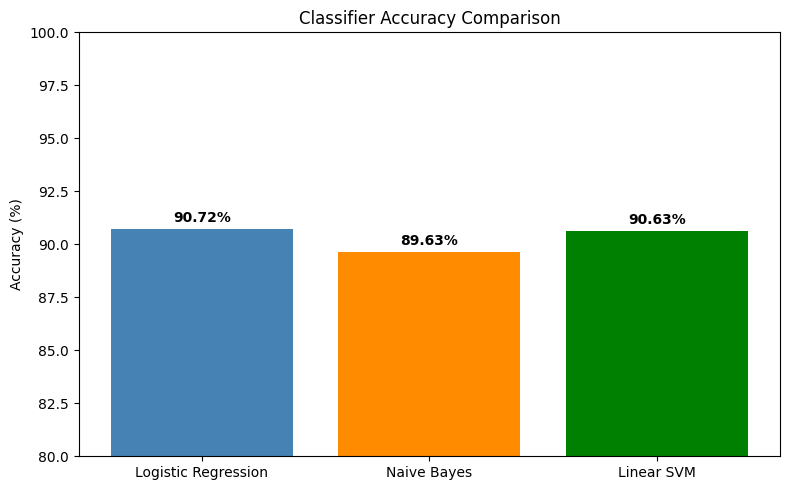

In [35]:
import matplotlib.pyplot as plt

classifiers = ['Logistic Regression', 'Naive Bayes', 'Linear SVM']
accuracies = [
    accuracy_score(y_test, y_pred) * 100,
    accuracy_score(y_test, y_pred_nb) * 100,
    accuracy_score(y_test, y_pred_svm) * 100
]

plt.figure(figsize=(8, 5))
bars = plt.bar(classifiers, accuracies, color=['steelblue', 'darkorange', 'green'])
plt.ylim(80, 100)
plt.ylabel('Accuracy (%)')
plt.title('Classifier Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()